## --- Generate text with a recurrent neural network (Pytorch) ---
### (Mostly Read & Run)

The goal is to replicate the (famous) experiment from [Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

To learn to generate text, we train a recurrent neural network to do the following task:

Given a "chunk" of text: `this is random text`

the goal of the network is to predict each character in **`his is random text` ** sequentially given the following sequential input **`this is random tex`**:




## Load text (dataset/input.txt)

Before building training batch, we load the full text in RAM

In [1]:
!wget https://thome.isir.upmc.fr/classes/RITAL/input.txt

--2026-03-29 23:06:53--  https://thome.isir.upmc.fr/classes/RITAL/input.txt
Resolving thome.isir.upmc.fr (thome.isir.upmc.fr)... 134.157.18.247
Connecting to thome.isir.upmc.fr (thome.isir.upmc.fr)|134.157.18.247|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.07s   

2026-03-29 23:06:54 (14.3 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [2]:
#! pip install unidecode

In [3]:
import unidecode
import string
import random
import re
import torch
import torch.nn as nn

all_characters = string.printable
n_characters = len(all_characters)

file = unidecode.unidecode(open('./input.txt').read()) #clean text => only ascii
file_len = len(file)
print('file_len =', file_len)


file_len = 1115394


## 2: Helper functions:

We have a text and we want to feed batch of chunks to a neural network:

one chunk  A,B,C,D,E
[input] A,B,C,D -> B,C,D,E [output]

Note: we will use an embedding layer instead of a one-hot encoding scheme.

for this, we have 3 functions:

- One to get a random str chunk of size `chunk_len` : `random_chunk`
- One to turn a chunk into a tensor of size `(1,chunk_len)` coding for each characters : `char_tensor`
- One to return random input and output chunks of size `(batch_size,chunk_len)` : `random_training_set`




In [4]:
import time, math


#Get a piece of text
def random_chunk(chunk_len):
    start_index = random.randint(0, file_len - chunk_len)
    end_index = start_index + chunk_len + 1
    return file[start_index:end_index]


# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(1,len(string)).long()
    for c in range(len(string)):
        tensor[0,c] = all_characters.index(string[c])
    return tensor


#Turn a piece of text in train/test
def random_training_set(chunk_len=200, batch_size=8):
    chunks = [random_chunk(chunk_len) for _ in range(batch_size)]
    inp = torch.cat([char_tensor(chunk[:-1]) for chunk in chunks],dim=0)
    target = torch.cat([char_tensor(chunk[1:]) for chunk in chunks],dim=0)

    return inp, target

print(random_training_set(10,4))  ## should return 8 chunks of 10 letters.

(tensor([[14, 73, 96, 41, 24, 27, 94, 29, 17, 14],
        [13, 94, 28, 17, 14, 94, 20, 23, 14, 14],
        [18, 21, 34, 62, 96, 96, 38, 50, 53, 44],
        [75, 96, 96, 42, 47, 50, 56, 38, 40, 54]]), tensor([[73, 96, 41, 24, 27, 94, 29, 17, 14, 18],
        [94, 28, 17, 14, 94, 20, 23, 14, 14, 21],
        [21, 34, 62, 96, 96, 38, 50, 53, 44, 50],
        [96, 96, 42, 47, 50, 56, 38, 40, 54, 55]]))


## The actual RNN model (only thing to complete):

It should be composed of three distinct modules:

- an [embedding layer](https://pytorch.org/docs/stable/nn.html#embedding) (n_characters, hidden_size)

```
nn.Embedding(len_dic,size_vec)
```
- a [recurrent](https://pytorch.org/docs/stable/nn.html#recurrent-layers) layer (hidden_size, hidden_size)
```
nn.RNN(in_size,out_size) or nn.GRU() or nn.LSTM() => rnn_cell parameter
```
- a [prediction](https://pytorch.org/docs/stable/nn.html#linear) layer (hidden_size, output_size)

```
nn.Linear(in_size,out_size)
```
=> Complete the `init` function code

In [5]:
import torch.nn.functional as f

class RNN(nn.Module):

    def __init__(self, n_char, hidden_size, output_size, n_layers=1,rnn_cell=nn.RNN):
        """
        Create the network
        """
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        #  (batch,chunk_len) -> (batch, chunk_len, hidden_size)
        self.embed = nn.Embedding(n_char, hidden_size)

        # (batch, chunk_len, hidden_size)  -> (batch, chunk_len, hidden_size)
        self.rnn = rnn_cell(hidden_size, hidden_size, num_layers=n_layers, batch_first=True)

        #(batch, chunk_len, hidden_size) -> (batch, chunk_len, output_size)
        self.predict = nn.Linear(hidden_size, output_size)

    def forward(self, input):
        """
        batched forward: input is (batch > 1,chunk_len)
        """
        input = self.embed(input)
        output,_  = self.rnn(input)
        output = self.predict(f.tanh(output))
        return output

    def forward_seq(self, input,hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output,hidden  = self.rnn(input.unsqueeze(0),hidden)
        output = self.predict(f.tanh(output))
        return output,hidden


## Text generation function

Sample text from the model

In [10]:
def generate(model,prime_str='A', predict_len=100, temperature=0.8):
    model.eval()
    device = next(model.parameters()).device
    prime_input = char_tensor(prime_str).squeeze(0).to(device)
    hidden = None
    predicted = prime_str+""
    # Use priming string to "build up" hidden state

    safe_temperature = max(float(temperature), 1e-4)

    for p in range(len(prime_str)-1):
        _,hidden = model.forward_seq(prime_input[p].unsqueeze(0),hidden)

    #print(hidden.size())
    for p in range(predict_len):
        output, hidden = model.forward_seq(prime_input[-1].unsqueeze(0), hidden)
        # Numerically stable sampling (important for low temperatures)
        logits = output[0, -1] / safe_temperature
        probs = torch.softmax(logits, dim=0)
        probs = torch.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)

        if probs.sum() <= 0:
            probs = torch.ones_like(probs) / probs.numel()
        else:
            probs = probs / probs.sum()

        top_i = torch.multinomial(probs, 1)[0]

        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i.item()]
        predicted += predicted_char
        prime_input = torch.cat([prime_input, top_i.view(1)])

    return predicted



## Training loop for net

In [7]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('Using device:', device)

model = RNN(n_characters, hidden_size, n_characters, n_layers).to(device) #create model
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr) #create Adam optimizer
criterion = nn.CrossEntropyLoss() #chose criterion

start = time.time()
all_losses = []
loss_avg = 0


def train(inp, target):
    """
    Train sequence for one chunk:
    """
    inp = inp.to(device)
    target = target.to(device)

    #reset gradients
    model_optimizer.zero_grad()

    # predict output
    output = model(inp)

    #compute loss
    loss =  criterion(output.view(batch_size*chunk_len,-1), target.view(-1))

    #compute gradients and backpropagate
    loss.backward()
    model_optimizer.step()

    return loss.data.item()


for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(model,'Wh', 100), '\n')


    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


Using device: mps
 14s (100 0%) 2.7335]
Whn mas Ithe fhhs todw hos tLA:
mO
in oulgt wrmoe'elinl ns osdd wiee Titein LcAor, tbohn? Wrirded is m 

 27s (200 1%) 2.3368]
Whaun: on hataut not, this a lwisimr'ile to natesd
Hor thoad the rarded and lo wyllel med doaun, mriun 

 40s (300 1%) 2.2684]
Whe sit, thild lord ocilp me I the thean thitias enerd a: shut't thou shaninnt gid gork aworge sase.

 

 52s (400 2%) 2.1579]
When sis fod thof poletemer'ge heaunge
I fond our noland
Iwaut pronk thenimess nopter and I blofesd no 

 4s (500 2%) 2.1037]
What charrure mees in aume bary bixe! and whest, made wear
Thither, thine and
Oo me, here?

She so at  

 16s (600 3%) 2.0589]
White and thard avereth, man at the umlk't the niven tore the do.

ISWI:
But to whet, thage a saemed's 

 29s (700 3%) 1.9473]
Whe me,
Gatan.

dow ilanle of cerlly ve tone thou the sortell to so thall he mey afor,
In Er't his in  

 41s (800 4%) 2.0206]
Whe
Whes horry me,
Them pull you, grylwour own be't;
And the is for bone

## Visualize loss

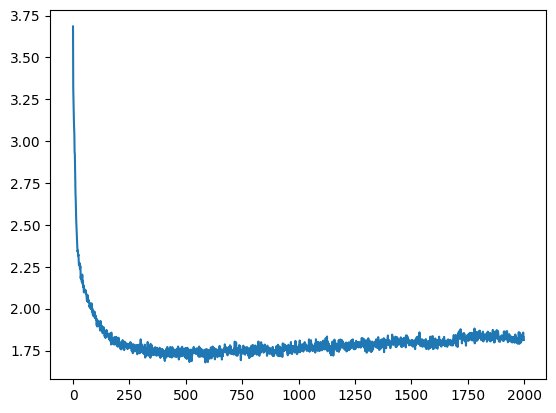

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

## Try different temperatures

Changing the distribution sharpness has an impact on character sampling:

more or less probable things are sampled

In [11]:
print(generate(model,'T', 200, temperature=1))
print("----")
print(generate(model,'Th', 200, temperature=0.8))
print("----")

print(generate(model,'Th', 200, temperature=0.5))
print("----")

print(generate(model,'Th', 200, temperature=0.3))
print("----")

print(generate(model,'Th', 200, temperature=0.1))

TERIS:
So,
Came, fear I deets,
Ange.

DORIO:

MARCIDRIUS:
Enour inter; pay?

BUHHARD:
Weingal.

FLOURIES:
How's ceur death as
to this land.

PAPKIS:
Herent hermies's,--Ryonge any I warwinet-myself.

KA
----
Thas the weerrims im repel your tor.

BUCDOSSOS:
I fear!

ALILEO:
Haw'd in rast, what your bear of everf since be siswalk murportune;
And me your tontlecmend.

GARYRIUS:
What have good, and pendence, be
----
Thepher the that from the fear.

DORK:
That shall well this have and me of the have with the then than since of the resolve you dirnen not say and the face of the consures, I word the sound, sir will th
----
Than the shall be that shall still.

DUKE OF YORK:
And shall face the and stay for the have since the from the be succorter the to the am the bedy to thy stay to be so a death here and a sort we have wi
----
This shall so the shall so the from the shall so the son the shall so the shall so the bear and the shall shall for the shall so the shall the shall and the shall so the

### Improving this code:

(a) Tinker with parameters:

- Is it really necessary to have 100 dims character embeddings
- Chunk length can be gradually increased
- Try changing RNN cell type (GRUs - LSTMs)

(b) Add GPU support to go faster


In [12]:
# Optional quick check: confirm where the model is running
print('Model device:', next(model.parameters()).device)

Model device: mps:0


## 8. Answers and takeaways

**What does the model learn?**  
It learns a probability distribution over the next character conditioned on
the previous ones. That is already enough to imitate style, punctuation,
and some local syntax.

**What is the role of the embedding layer?**  
Instead of feeding a sparse one-hot vector for each character, we learn a
dense representation. Characters that play similar roles can therefore end
up with similar vectors.

**How should we interpret temperature?**  
Higher temperatures create more diverse but noisier text. Lower
temperatures make the distribution peakier, so generation becomes more
conservative and often more repetitive.

**Is an embedding size of 100 or 128 necessary?**  
Not always. For a character vocabulary, even 32 or 64 dimensions can work.
Larger embeddings help expressiveness, but they also increase computation.

**Should chunk length be increased?**  
Usually yes, but progressively. Short chunks are easier to train with at
the beginning. Longer chunks help the model capture longer dependencies,
but they increase memory use and training time.

**Would GRUs or LSTMs help?**  
Yes. They generally model longer-range dependencies better than a plain
RNN because they control how information is stored and forgotten.

**How can we speed training up?**  
Move both the model and the batches to `cuda` or `mps`, exactly as done in
this notebook. On modern hardware, that gives a large speed-up.